# Algorithm Visualizations
Conceptual illustrations for thesis (e.g. getViolating scatter plot).

In [1]:
from chart_utils import *

## GetViolating Visualization

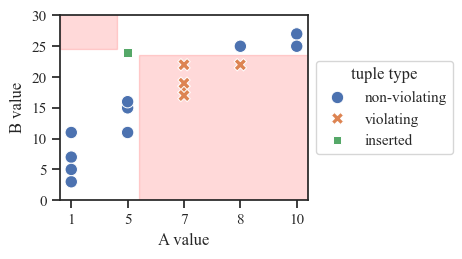

In [2]:
rows = [
  (1, 3, "non-violating"),
  (1, 7, "non-violating"),
  (1, 11, "non-violating"),
  (1, 5, "non-violating"),
  (5, 15, "non-violating"),
  (5, 16, "non-violating"),
  (5, 11, "non-violating"),
  (7, 22, "violating"),
  (7, 18, "violating"),
  (7, 19, "violating"),
  (7, 17, "violating"),
  (8, 22, "violating"),
  (8, 25, "non-violating"),
  (10, 27, "non-violating"),
  (10, 25, "non-violating"),
  (5, 24, "inserted")
]

compatible_getviolating_example = pd.DataFrame(
  rows, columns=["A value", "B value", "tuple type"]
)
plot_df = compatible_getviolating_example.copy()
plot_df["tuple type"] = plot_df["tuple type"].fillna("Uncategorized")

# Get the inserted point coordinates
inserted_point = plot_df[plot_df["tuple type"] == "inserted"]
insert_x = inserted_point["A value"].values[0]
insert_y = inserted_point["B value"].values[0]

# Create the scatter plot
plot_df["A value"] = plot_df["A value"].astype(str)
ax = sns.scatterplot(data=plot_df, x="A value", y="B value", style="tuple type", hue="tuple type", markers=True, s=80)

# Get unique x values for plotting
unique_x = sorted(plot_df["A value"].unique(), key=lambda x: int(x))
x_positions = {str(x): i for i, x in enumerate(unique_x)}

# Get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Shade top-left area (x < insert_x, y > insert_y)
ax.axhspan(insert_y + 0.5, ylim[1] + 10, xmin=0, xmax=(x_positions[str(insert_x)] + 0.15) / len(unique_x), alpha=0.15, color='red', zorder=0)

# Shade bottom-right area (x > insert_x, y < insert_y)
ax.axhspan(0, insert_y - 0.5, xmin=(x_positions[str(insert_x)] + 0.6) / len(unique_x), xmax=1, alpha=0.15, color='red', zorder=0)

ax.set_ylim(bottom=0, top=30)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5), ncols=1)

save_figure("getviolating_visualization", scaling=0.5)
plt.show()